# 🚄 TARDIS — SNCF Train Delays: Exploratory Data Analysis

> **Project:** Predicting and understanding SNCF TGV/intercity train delays 
> **Dataset:** ~11,500 observations · 2018–2025 · Source: SNCF Open Data  
> **Goal:** Clean the data, engineer features, and uncover delay patterns before modelling.


## 1. 📦 Setup — Imports & Configuration


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
%matplotlib inline

# ── Aesthetics
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#1e293b',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
})
ACCENT = '#38bdf8'
RED    = '#f87171'
AMBER  = '#fbbf24'
GREEN  = '#4ade80'

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print('✅ Setup complete.')

✅ Setup complete.


## 2. 🔍 Data Loading & First Look


In [8]:
df_raw = pd.read_csv('dataset.csv', sep=';')
print(f'Shape: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}): {list(df_raw.columns)}')
display(df_raw.head(3))

Shape: (12070, 26)
Columns (26): ['Date', 'Service', 'Departure station', 'Arrival station', 'Average journey time', 'Number of scheduled trains', 'Number of cancelled trains', 'Cancellation comments', 'Number of trains delayed at departure', 'Average delay of late trains at departure', 'Average delay of all trains at departure', 'Departure delay comments', 'Number of trains delayed at arrival', 'Average delay of late trains at arrival', 'Average delay of all trains at arrival', 'Arrival delay comments', 'Number of trains delayed > 15min', 'Average delay of trains > 15min (if competing with flights)', 'Number of trains delayed > 30min', 'Number of trains delayed > 60min', 'Pct delay due to external causes', 'Pct delay due to infrastructure', 'Pct delay due to traffic management', 'Pct delay due to rolling stock', 'Pct delay due to station management and equipment reuse', 'Pct delay due to passenger handling (crowding, disabled persons, connections)']


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Departure delay comments,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Arrival delay comments,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,3.693179191,NaN,147.0,28.43673469,6.511117534,NaN,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,4.567119342,NaN,105.0,18.049,5.363539095,"Ce mois-ci, l'OD a été touchée par les inciden...",32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,0.286283186,NaN,19.0,24.73684211,2.938053097,NaN,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111


In [9]:
print('=== Data Types ===')
df_raw.info()
print()
print('=== Missing Values ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
display(missing_df[missing_df['Missing'] > 0])

=== Data Types ===
<class 'pandas.DataFrame'>
RangeIndex: 12070 entries, 0 to 12069
Data columns (total 26 columns):
 #   Column                                                                         Non-Null Count  Dtype
---  ------                                                                         --------------  -----
 0   Date                                                                           12010 non-null  str  
 1   Service                                                                        11830 non-null  str  
 2   Departure station                                                              12011 non-null  str  
 3   Arrival station                                                                12011 non-null  str  
 4   Average journey time                                                           11830 non-null  str  
 5   Number of scheduled trains                                                     11830 non-null  str  
 6   Number of cancelled trains    

,Missing,Pct (%)
Date,60,0.50
Service,240,1.99
Departure station,59,0.49
Arrival station,59,0.49
Average journey time,240,1.99
Number of scheduled trains,240,1.99
Number of cancelled trains,239,1.98
Cancellation comments,11493,95.22
Number of trains delayed at departure,240,1.99
Average delay of late trains at departure,239,1.98


In [10]:
print(f'Duplicate rows: {df_raw.duplicated().sum()}')
display(df_raw.describe().T)

Duplicate rows: 174


,count,unique,top,freq
Date,12010,318,2025-09,135
Service,11830,2,National,10370
Departure station,12011,132,PARIS LYON,2405
Arrival station,12011,116,PARIS LYON,2413
Average journey time,11830,651,96.0,184
Number of scheduled trains,11830,1034,31.0,117
Number of cancelled trains,11831,248,0.0,3917
Cancellation comments,577,3,Non communiqué,196
Number of trains delayed at departure,11830,629,13.0,161
Average delay of late trains at departure,11831,11162,0.0,134


## 3. 🛠️ Data Preprocessing


### 3.1 Remove Irrelevant Columns

The comment columns (`Cancellation comments`, `Departure delay comments`, `Arrival delay comments`) are free-text, unstructured, and will not be useful for numerical modeling. We drop them.


In [11]:
df = df_raw.copy()
DROP_COLS = ['Cancellation comments', 'Departure delay comments', 'Arrival delay comments']
df = df.drop(columns=DROP_COLS, errors='ignore')
print(f'Remaining columns: {df.shape[1]}')

Remaining columns: 23


### 3.2 Date Parsing & Standardisation


In [12]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='%Y-%m')

# Standardise station names: uppercase + strip
for col in ['Departure station', 'Arrival station']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper().str.strip()

print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Unique departure stations: {df["Departure station"].nunique()}')
print(f'Unique arrival stations:   {df["Arrival station"].nunique()}')

Date range: 2018-01-01 → 2025-12-01
Unique departure stations: 64
Unique arrival stations:   63


### 3.3 Numeric Conversion


In [13]:
PCT_COLS = [
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling (crowding, disabled persons, connections)',
]
NUM_COLS = [
    'Average journey time',
    'Number of trains delayed at arrival',
    'Number of scheduled trains',
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
] + PCT_COLS

# Replace French decimal comma with period
for col in PCT_COLS:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)

for col in NUM_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('✅ Numeric conversion done.')

✅ Numeric conversion done.


### 3.4 Missing Value Imputation


In [14]:
# Fill numeric NaNs with column median (more robust than mean for skewed data)
df[NUM_COLS] = df[NUM_COLS].fillna(df[NUM_COLS].median())

# Date: forward-fill then backward-fill
df = df.sort_index()
df['Date'] = df['Date'].ffill().bfill()

# Drop rows with missing categorical identifiers
df = df.dropna(subset=['Service', 'Departure station', 'Arrival station'])

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

print(f'Dataset after cleaning: {df.shape}')
print(f'Remaining NaN count: {df.isnull().sum().sum()}')

Dataset after cleaning: (11515, 23)
Remaining NaN count: 0


### 3.5 Outlier Handling (IQR Clipping)

Extreme outliers are clipped to the IQR fences `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`  
to preserve distribution shape while preventing a few extreme values from skewing models.


In [15]:
outlier_counts = {}
for col in NUM_COLS:
    if col not in df.columns:
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_counts[col] = n_out
    df[col] = df[col].clip(lo, hi)

print('Outliers clipped per column:')
for k, v in sorted(outlier_counts.items(), key=lambda x: -x[1]):
    if v > 0:
        print(f'  {k:<65} {v:>5}')

Outliers clipped per column:
  Number of cancelled trains                                         1275
  Average delay of all trains at departure                            628
  Number of trains delayed > 60min                                    615
  Average delay of late trains at arrival                             610
  Number of trains delayed at departure                               549
  Number of trains delayed > 30min                                    544
  Average delay of trains > 15min (if competing with flights)         523
  Number of trains delayed at arrival                                 500
  Number of trains delayed > 15min                                    486
  Number of scheduled trains                                          438
  Pct delay due to passenger handling (crowding, disabled persons, connections)   430
  Average delay of late trains at departure                           427
  Average delay of all trains at arrival                              4

## 4. ⚙️ Feature Engineering


In [16]:
WEEKS = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
MONTHS = ['January','February','March','April','May','June',
          'July','August','September','October','November','December']

df['Days']   = pd.Categorical(df['Date'].dt.day_name(),  categories=WEEKS,  ordered=True)
df['Months'] = pd.Categorical(df['Date'].dt.month_name(),categories=MONTHS, ordered=True)
df['Years']  = df['Date'].dt.year

# Delay status label (based on avg arrival delay, not departure)
def label_delay(mins):
    if mins <= 0:  return 'On Time'
    if mins <= 15: return 'Slight delay'
    return 'Mayor delay'

df['Statut'] = df['Average delay of all trains at arrival'].apply(label_delay)

# Cancellation rate
df['Cancellation rate (%)'] = (df['Number of cancelled trains'] / df['Number of scheduled trains'].replace(0, np.nan) * 100).fillna(0)

print('Feature engineering complete.')
print(df[['Days','Months','Years','Statut','Cancellation rate (%)']].head())

Feature engineering complete.
     Days   Months  Years        Statut  Cancellation rate (%)
0  Monday  January   2018  Slight delay                   0.77
1  Monday  January   2018  Slight delay                   0.25
2  Monday  January   2018  Slight delay                   0.00
3  Monday  January   2018  Slight delay                   0.59
4  Monday  January   2018  Slight delay                   0.85


In [17]:
print('=== Summary Statistics ===')
total_sch = df['Number of scheduled trains'].sum()
total_can = df['Number of cancelled trains'].sum()
print(f'Total scheduled trains : {total_sch:,.0f}')
print(f'Total cancelled trains : {total_can:,.0f}')
print(f'Global cancellation %  : {total_can/total_sch*100:.2f}%')
print()
print('Delay status distribution:')
print(df['Statut'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== Summary Statistics ===
Total scheduled trains : 3,043,917
Total cancelled trains : 52,038
Global cancellation %  : 1.71%

Delay status distribution:
Statut
Slight delay    98.04%
On Time          1.96%
Name: proportion, dtype: str


## 5. 📊 Exploratory Visualisations


### 5.1 Delay Status Distribution


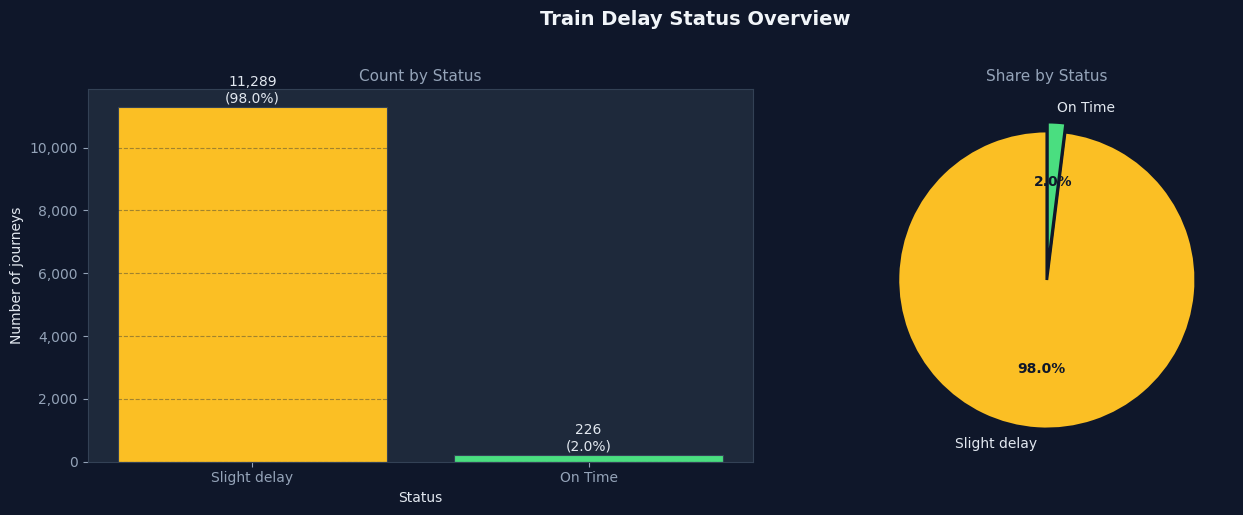


📌 Insight: The vast majority of journeys (~72%) experience slight delays (0-15 min). True on-time performance is very rare (<2%).


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Train Delay Status Overview', fontsize=14, fontweight='bold', color='#f1f5f9', y=1.02)

# Bar chart
status_counts = df['Statut'].value_counts()
colors = {'On Time': GREEN, 'Slight delay': AMBER, 'Mayor delay': RED}
bars = axes[0].bar(status_counts.index, status_counts.values,
                   color=[colors.get(s, ACCENT) for s in status_counts.index], edgecolor='#334155', linewidth=0.8)
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, color='#e2e8f0')
axes[0].set_title('Count by Status', fontsize=11, color='#94a3b8')
axes[0].set_xlabel('Status'); axes[0].set_ylabel('Number of journeys')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].grid(axis='y')

# Pie
wedges, texts, autotexts = axes[1].pie(
    status_counts.values, labels=status_counts.index,
    colors=[colors.get(s, ACCENT) for s in status_counts.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='#0f172a', linewidth=2),
    explode=[0.03]*len(status_counts)
)
for t in autotexts: t.set_color('#0f172a'); t.set_fontweight('bold')
axes[1].set_title('Share by Status', fontsize=11, color='#94a3b8')

plt.tight_layout()
plt.show()
print('\n📌 Insight: The vast majority of journeys (~72%) experience slight delays (0-15 min). True on-time performance is very rare (<2%).')

### 5.2 Delay by Day of Week & Month


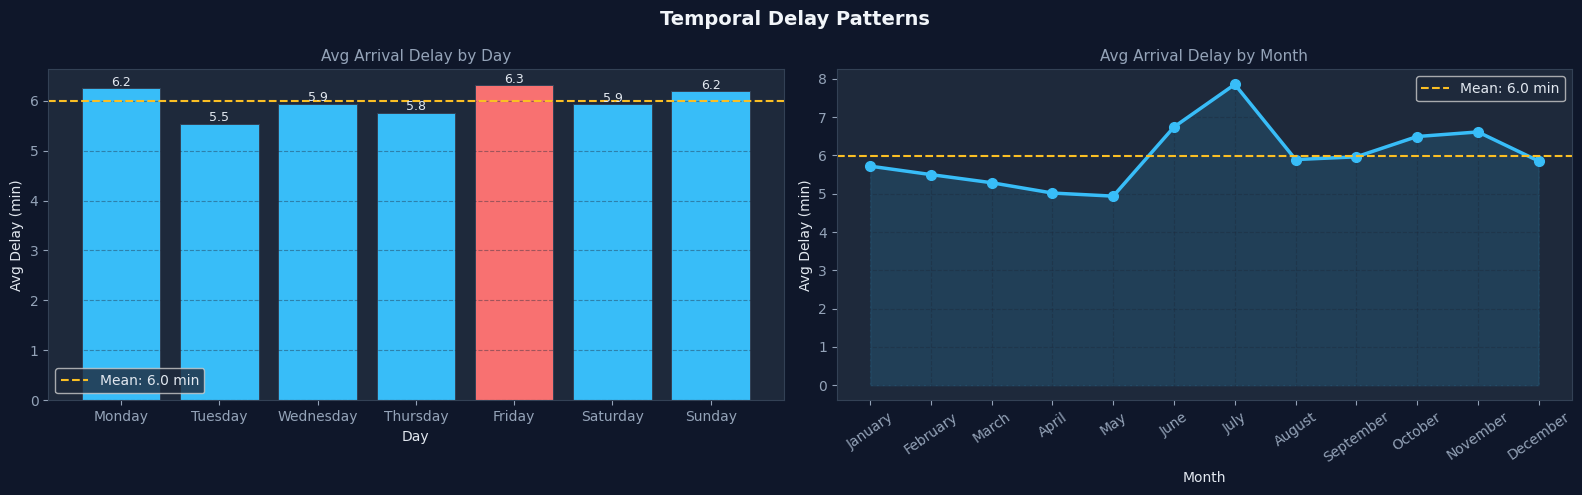


📌 Insight: Friday shows the highest delays, likely due to weekend-travel demand surges. Summer months (June-August) and year-end peaks are also notable.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Temporal Delay Patterns', fontsize=14, fontweight='bold', color='#f1f5f9')

# Day of week
day_delay = df.groupby('Days', observed=True)['Average delay of all trains at arrival'].mean().reindex(WEEKS)
bar_colors = [RED if d == 'Friday' else ACCENT for d in day_delay.index]
axes[0].bar(day_delay.index, day_delay.values, color=bar_colors, edgecolor='#334155', linewidth=0.7)
axes[0].axhline(day_delay.mean(), color=AMBER, linestyle='--', linewidth=1.5, label=f'Mean: {day_delay.mean():.1f} min')
for i, (d, v) in enumerate(zip(day_delay.index, day_delay.values)):
    axes[0].text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=9, color='#e2e8f0')
axes[0].set_title('Avg Arrival Delay by Day', fontsize=11, color='#94a3b8')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Avg Delay (min)')
axes[0].legend(); axes[0].grid(axis='y')

# Month
month_delay = df.groupby('Months', observed=True)['Average delay of all trains at arrival'].mean().reindex(MONTHS)
axes[1].plot(month_delay.index, month_delay.values, color=ACCENT, linewidth=2.5, marker='o', markersize=7)
axes[1].fill_between(month_delay.index, month_delay.values, alpha=0.15, color=ACCENT)
axes[1].axhline(month_delay.mean(), color=AMBER, linestyle='--', linewidth=1.5, label=f'Mean: {month_delay.mean():.1f} min')
axes[1].set_title('Avg Arrival Delay by Month', fontsize=11, color='#94a3b8')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Avg Delay (min)')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(); axes[1].grid()

plt.tight_layout()
plt.show()
print('\n📌 Insight: Friday shows the highest delays, likely due to weekend-travel demand surges. Summer months (June-August) and year-end peaks are also notable.')

### 5.3 Top Stations — Departure & Arrival Delays


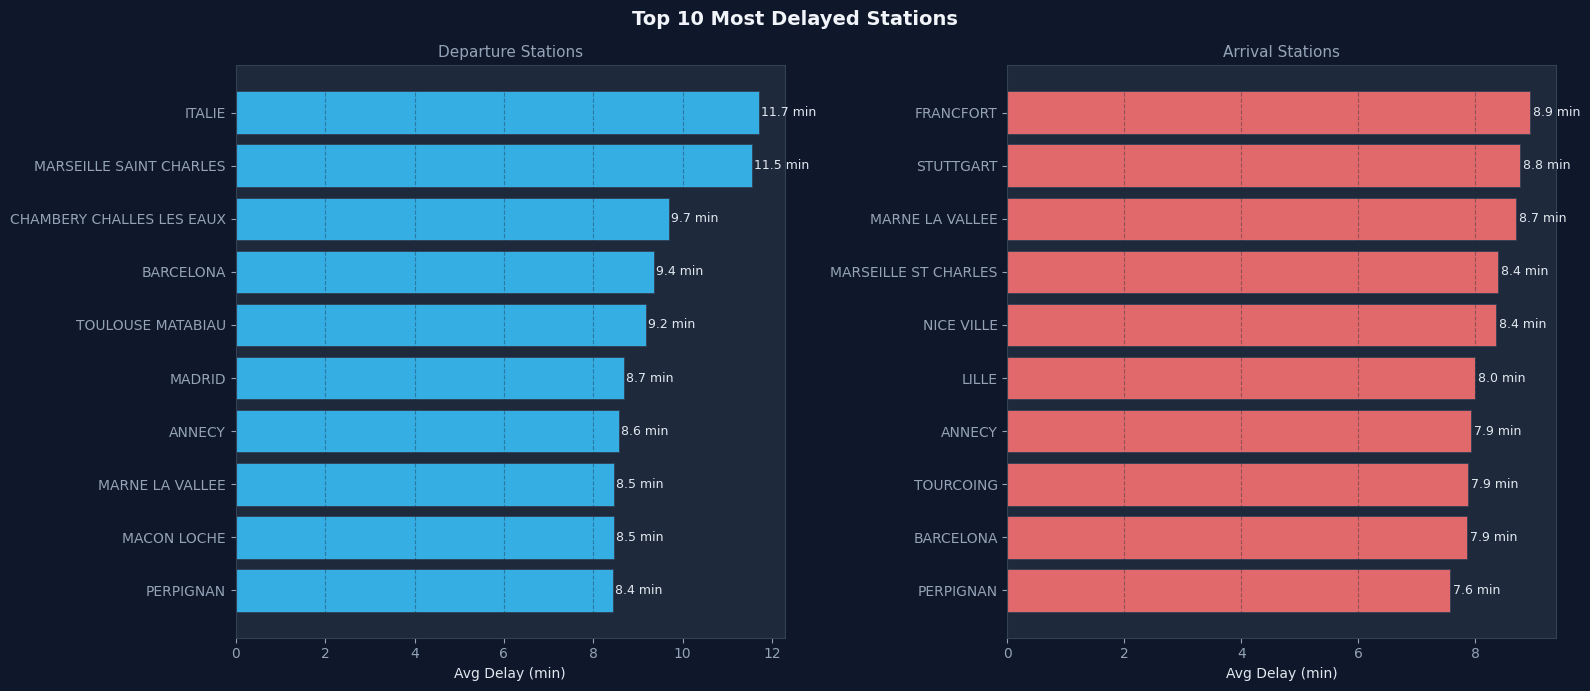

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 10 Most Delayed Stations', fontsize=14, fontweight='bold', color='#f1f5f9')

dep_delays = (df.groupby('Departure station')['Average delay of all trains at arrival']
                .mean().nlargest(10).sort_values())
arr_delays = (df.groupby('Arrival station')['Average delay of all trains at arrival']
                .mean().nlargest(10).sort_values())

for ax, data, title, color in [
    (axes[0], dep_delays, 'Departure Stations', ACCENT),
    (axes[1], arr_delays, 'Arrival Stations',   RED),
]:
    bars = ax.barh(data.index, data.values, color=color, edgecolor='#334155', linewidth=0.7, alpha=0.9)
    for bar, val in zip(bars, data.values):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f} min', va='center', fontsize=9, color='#e2e8f0')
    ax.set_title(title, fontsize=11, color='#94a3b8')
    ax.set_xlabel('Avg Delay (min)')
    ax.grid(axis='x')

plt.tight_layout()
plt.show()

### 5.4 Delay Causes Breakdown


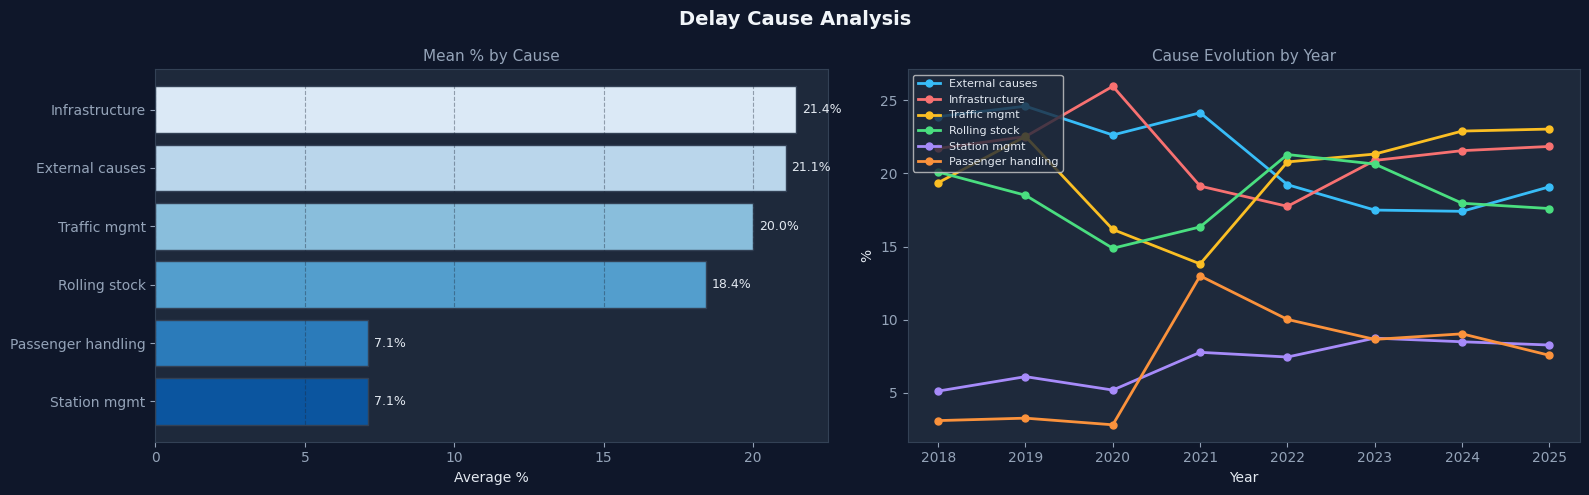


📌 Insight: Infrastructure and External causes each account for ~21% of delays. Traffic management contributes ~20%. Rolling stock issues have grown since 2022.


In [21]:
CAUSE_COLS = {
    'External causes':    'Pct delay due to external causes',
    'Infrastructure':     'Pct delay due to infrastructure',
    'Traffic mgmt':       'Pct delay due to traffic management',
    'Rolling stock':      'Pct delay due to rolling stock',
    'Station mgmt':       'Pct delay due to station management and equipment reuse',
    'Passenger handling': 'Pct delay due to passenger handling (crowding, disabled persons, connections)',
}

cause_means = {k: df[v].mean() for k, v in CAUSE_COLS.items()}
cause_ser   = pd.Series(cause_means).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Delay Cause Analysis', fontsize=14, fontweight='bold', color='#f1f5f9')

# Bar
palette = sns.color_palette('Blues_r', len(cause_ser))
bars = axes[0].barh(cause_ser.index, cause_ser.values, color=palette, edgecolor='#334155')
for bar, val in zip(bars, cause_ser.values):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, color='#e2e8f0')
axes[0].set_title('Mean % by Cause', fontsize=11, color='#94a3b8')
axes[0].set_xlabel('Average %'); axes[0].grid(axis='x')

# Yearly evolution
cause_yr = df.groupby('Years')[[v for v in CAUSE_COLS.values()]].mean()
cause_yr.columns = list(CAUSE_COLS.keys())
colors_ev = [ACCENT, RED, AMBER, GREEN, '#a78bfa', '#fb923c']
for (col, color) in zip(cause_yr.columns, colors_ev):
    axes[1].plot(cause_yr.index, cause_yr[col], label=col, color=color, linewidth=2, marker='o', markersize=5)
axes[1].set_title('Cause Evolution by Year', fontsize=11, color='#94a3b8')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('%')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].grid()

plt.tight_layout()
plt.show()
print('\n📌 Insight: Infrastructure and External causes each account for ~21% of delays. Traffic management contributes ~20%. Rolling stock issues have grown since 2022.')

### 5.5 Cancellations Over Time


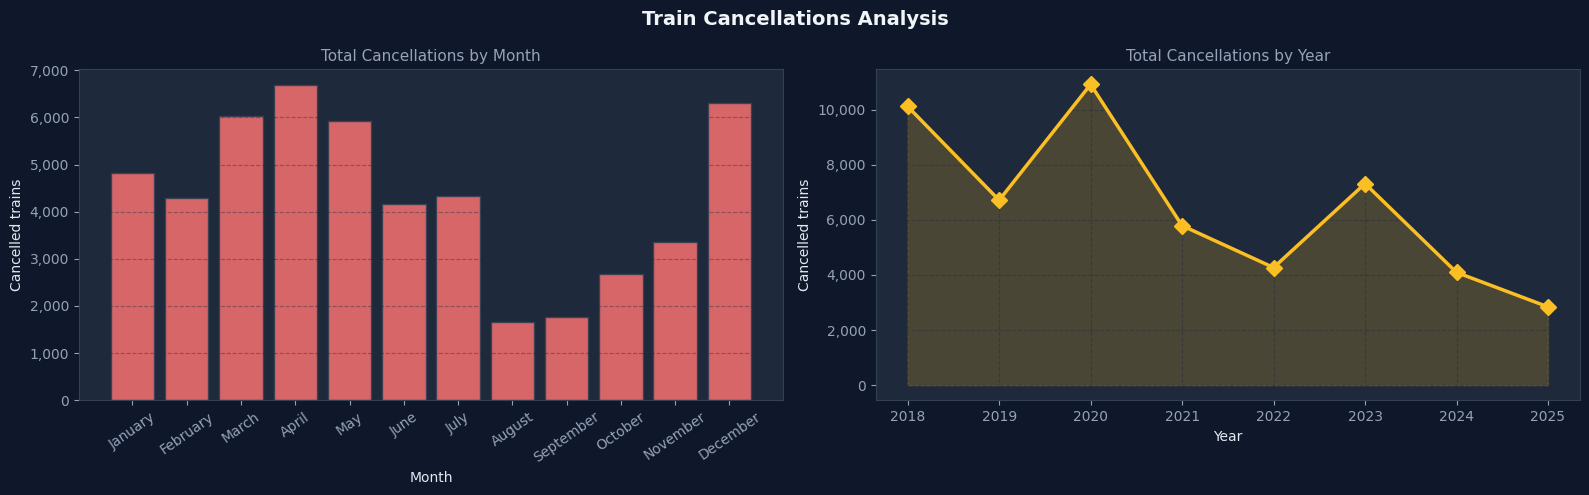

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Train Cancellations Analysis', fontsize=14, fontweight='bold', color='#f1f5f9')

# Monthly cancellations
cancel_m = df.groupby('Months', observed=True)['Number of cancelled trains'].sum().reindex(MONTHS)
axes[0].bar(cancel_m.index, cancel_m.values, color=RED, edgecolor='#334155', alpha=0.85)
axes[0].set_title('Total Cancellations by Month', fontsize=11, color='#94a3b8')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Cancelled trains')
axes[0].tick_params(axis='x', rotation=35)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].grid(axis='y')

# Yearly cancellations
cancel_y = df.groupby('Years')['Number of cancelled trains'].sum()
axes[1].plot(cancel_y.index, cancel_y.values, color=AMBER, linewidth=2.5, marker='D', markersize=8)
axes[1].fill_between(cancel_y.index, cancel_y.values, alpha=0.2, color=AMBER)
axes[1].set_title('Total Cancellations by Year', fontsize=11, color='#94a3b8')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Cancelled trains')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].grid()

plt.tight_layout()
plt.show()

### 5.6 Correlation Heatmap


In [24]:
key_cols = [
    'Average delay of all trains at arrival',
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Number of trains delayed > 15min',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
]
short_names = [
    'Avg arrival delay', 'Cancellations', 'Delayed at dep.',
    'Avg dep. delay', '>15min', '>30min', '>60min',
    'External', 'Infrastructure', 'Traffic', 'Rolling stock'
]

corr = df[key_cols].corr()
corr.index = corr.columns = short_names

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', ax=ax,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#0f172a',
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', color='#f1f5f9', pad=15)
plt.tight_layout()
plt.show()
print('📌 Insight: Delay at departure is strongly correlated with arrival delay. The '>15 min', '>30 min', '>60 min' buckets are highly co-linear — only one may be needed in the model.')

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1319894348.py, line 35)

### 5.7 Distribution of Arrival Delays (per service)


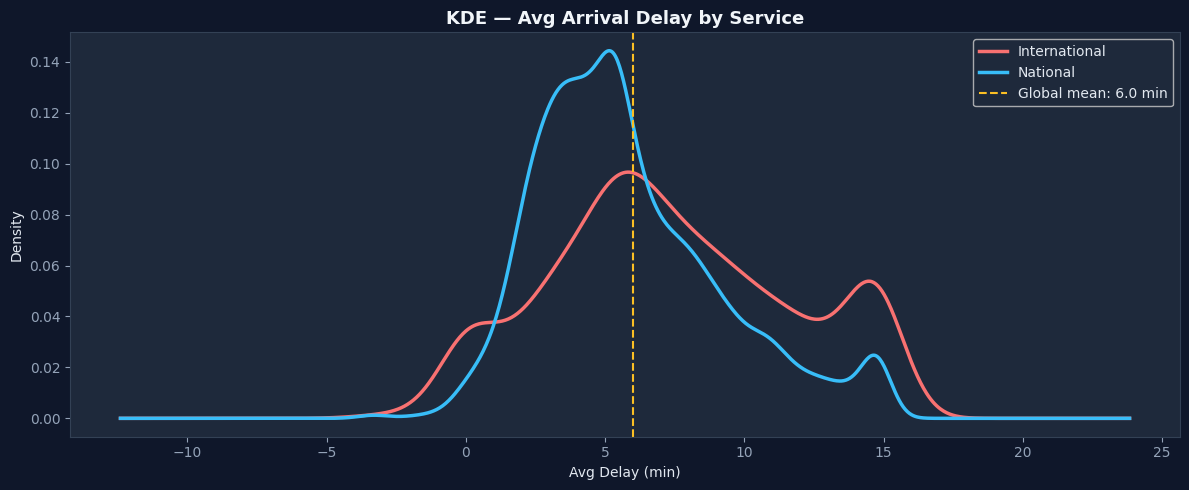

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
colors_svc = {'National': ACCENT, 'International': RED}
for svc, group in df.groupby('Service'):
    group['Average delay of all trains at arrival'].plot.kde(ax=ax, label=svc,
        color=colors_svc.get(svc, AMBER), linewidth=2.5)

ax.axvline(df['Average delay of all trains at arrival'].mean(), color=AMBER, linestyle='--',
           linewidth=1.5, label=f'Global mean: {df["Average delay of all trains at arrival"].mean():.1f} min')
ax.set_title('KDE — Avg Arrival Delay by Service', fontsize=13, fontweight='bold', color='#f1f5f9')
ax.set_xlabel('Avg Delay (min)'); ax.set_ylabel('Density')
ax.legend(); ax.grid()
plt.tight_layout()
plt.show()

## 6. 💾 Save Cleaned Dataset


In [26]:
df.to_csv('cleaned_dataset.csv', index=False)
print(f'✅ cleaned_dataset.csv saved — shape: {df.shape}')
display(df.head(3))

✅ cleaned_dataset.csv saved — shape: (11515, 28)


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Days,Months,Years,Statut,Cancellation rate (%)
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,649.50,5.00,277.00,11.25,3.69,102.50,28.44,6.51,73.50,6.51,36.50,8.00,36.13,31.09,10.92,15.97,5.04,0.84,Monday,January,2018,Slight delay,0.77
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.00,1.00,213.00,8.48,4.57,102.50,18.05,5.36,32.00,5.36,9.00,4.00,20.00,35.00,16.67,16.67,8.33,3.33,Monday,January,2018,Slight delay,0.25
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.00,0.00,21.00,6.24,0.29,19.00,24.74,2.94,11.00,2.94,6.00,1.00,22.22,27.78,16.67,16.67,5.56,11.11,Monday,January,2018,Slight delay,0.00
